#  $0-\pi$ Geometric Phase CZ Gate:

Model the 0-pi Hamiltonian from [Andras' Paper](https://journals.aps.org/prxquantum/pdf/10.1103/PRXQuantum.2.010339):

$$\begin{align}
&\hat{H}_{0-\pi} = 4 E_C^\theta(\hat{n}_\theta - n_g^\theta)^2 + 4E_C^\phi \hat{n}^2_\phi - 2E_J\cos(\hat{\theta})\cos(\hat{\phi}-\frac{\pi \Phi_{ext}}{\Phi_0}) + E_L\hat{\phi}^2 
\end{align}$$

Note that the scQubits Hamiltonian is slightly different:

$$\begin{align}
&\hat{H}_{0-\pi, scq} = 2 E_{C\Sigma}(\hat{n}_\theta - n_g^\theta)^2 + 2E_{CJ}\hat{n}^2_\phi - 2E_J\cos(\hat{\theta})\cos(\hat{\phi}-\frac{\pi \Phi_{ext}}{\Phi_0}) + E_L\hat{\phi}^2 
\end{align}$$

So some factors of two are added relative to the paper for the $E_C$ values.

The idea is to perform a CPHASE gate by way of resonant or near-resonant oscillations with one of the large matrix element higher excited states. If a drive is able to only excite a single computational state, then it will pick up a relative phase, and if we can make this relative phase equal to $\pi$, we have a CZ gate! In order to do this, we need the coupling interaction to cause $\omega_{\widetilde{e2}} - \omega_{\widetilde{22}} \neq \omega_{\widetilde{e0}} - \omega_{\widetilde{20}}$ or $\omega_{\widetilde{e2}} - \omega_{\widetilde{02}} \neq \omega_{\widetilde{e0}} - \omega_{\widetilde{00}}$, where the tilde $\widetilde{|ij\rangle}$ signifies the dressed state the corresponds to the $|ij\rangle$ bare state. In other words, the interaction causes the transition frequency to an excited state of one of the qubits to shift based on the state of the other, allowing us to isolate a single transition. This happens when there is some mixing between a pair of excited states.

<p align="center" width="100%">
    <img width="35%" src="2023-08-14-12-21-10.png">
</p>

# Outline:
#### 1) Define qubits and coupling
- Import libraries
- Initialize scQubits system
- Look at coupling
- Look at dressed states

#### 2) Determine which transition is the "best"
- Dependency of energy splittings on $E_J$
- Dependency of energy splittings on $g$

#### 3) Demonstrate gate & calculate fidelity

#### 4) Predict geometric phase accumulation

#### 5) Optimze gate for maximum fidelility in the absense of decoherence

# 1) Define qubits and coupling

In [11]:
import  os
num_cores = "1"
os.environ["OPENBLAS_NUM_THREADS"] = num_cores
os.environ["OMP_NUM_THREADS"] = num_cores
os.environ["MKL_NUM_THREADS"] = num_cores

In [2]:
import sys
sys.path.append('../')

# Necessary Imports
import numpy as np
import scipy.sparse as ssp
import matplotlib.pyplot as plt
%matplotlib inline
from tqdm import tqdm
import qutip as qt
import scqubits as scq
import matplotlib as mpl
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=mpl.colors.TABLEAU_COLORS) 
from qutip.qip.operations import rz, cz_gate
import cmath
from IPython.display import display, Math

import scqubits.settings as settings
settings.OVERLAP_THRESHOLD = 0.4

from scipy.optimize import minimize
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter

# import utils

## Qubit initialization

We couple the $n_{\theta_a} n_{\theta_b}$ modes together, as that is the only coupling that creates significant interaction in the lower states ($<=10$).

In [3]:
g = 0.091

# Number of eigenstates for each qubit to consider in the joint system
trunc_dim = 10 


# System Constants for each qubit
ng_theta = [0., 0.]
phi_ext = [0, 0]
EJ = [6.013, 6.013*0.9]
EL = [0.377, 0.377]
EC_theta = [0.092, 0.092 ] 
EC_phi = [1.142, 1.142 ]  

# Define the qubit and system
phi_grid = scq.Grid1d(-6*np.pi, 6*np.pi, 200)
zp1 = scq.ZeroPi(grid = phi_grid,
                 EJ = EJ[0],
                 EL = EL[0],
                 ECJ = 2 * EC_phi[0],
                 ECS = 2 * EC_theta[0],
                 EC = None,
                 ng = ng_theta[0],
                 flux = phi_ext[0],
                 ncut = 30,
                 truncated_dim = trunc_dim)
zp2 = scq.ZeroPi(grid = phi_grid,
                 EJ = EJ[1],
                 EL = EL[1],
                 ECJ = 2 * EC_phi[1],
                 ECS = 2 * EC_theta[1],
                 EC = None,
                 ng = ng_theta[1],
                 flux = phi_ext[1],
                 ncut = 30,
                 truncated_dim = trunc_dim)
hspace = scq.HilbertSpace([zp1, zp2])

hspace.add_interaction(g=g, op1=zp1.n_theta_operator, op2=zp2.n_theta_operator)
hspace.generate_lookup()


computational_subspace = [(0,0), (0,2), (2,0), (2,2)]

## Coupling Matrix

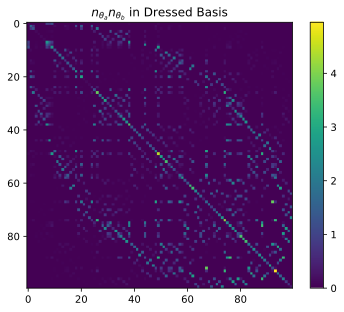

In [5]:
n_a = hspace.op_in_dressed_eigenbasis(zp1.n_theta_operator)
n_b = hspace.op_in_dressed_eigenbasis(zp2.n_theta_operator)
coupling = n_a*n_b
plt.imshow(np.abs(coupling.data.todense()))
plt.title(r"$n_{\theta_a}n_{\theta_b}$ in Dressed Basis")
plt.colorbar();

Try to find all non-diagonal matrix elements that are large (so states are coupled and will shift) and which have strong ability to drive to from the compuational subspace (to see which coupled states might be useful for the gate):

In [6]:
coupled = []
initial_states = []

# Threshold on coupling/drive mat elems respectively
thresh1 = 0.5
thresh2 = 0.5

# Loop through all dressed states
for i in range(coupling.shape[0]):
    for j in range(coupling.shape[1]):
        # Avoid diagonal
        if i != j:
            # Calculate coupling and drive strength
            couple_str = np.abs(coupling[i,j])
            drive_str = 0
            initial_state = (0,0)
            # For drive strength, only consider driving from computational subspace
            # to index i. By virtue of loop we'll still consider everything.
            for i0 in [hspace.dressed_index(x) for x in computational_subspace]:
                # Drive qubit a
                if np.abs(n_a[i0, i]) > drive_str:
                    drive_str = np.abs(n_a[i0, i])
                    initial_state = i0
                # Drive qubit b
                if np.abs(n_b[i0, i]) > drive_str:
                    drive_str = np.abs(n_b[i0, i])
                    initial_state = i0                    
            # If it clears both bars, record the state
            if couple_str >= thresh1 and drive_str >= thresh2:
                if hspace.bare_index(i) not in coupled:
                    coupled.append(hspace.bare_index(i))
                    initial_states.append(hspace.bare_index(initial_state))

# Look at unique excited states that have strong coupling & are able to be driven into from computational space
# First list is the state we'd be driving to, second list is the state we'd be driving from
coupled, initial_states

([(0, 1), (1, 0), (0, 5), (2, 1), (1, 2), (5, 0), (2, 5), (5, 2)],
 [(0, 0), (0, 0), (0, 2), (2, 0), (0, 2), (2, 0), (2, 2), (2, 2)])

## Dressed States

We've identified 8 excited states that may be useful for gates! Now let's look at them in more detail. Show their decomposition into bare states:

In [7]:
for state in coupled:
    display(Math(utils.dressed_state_decomp(hspace, state, (10,10), thresh=0.1, float_round=2)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

We see that the states split into four pairs that hybridize:

1) $\widetilde{|0,1\rangle} \& \widetilde{|1,0\rangle}$, acessible via $\widetilde{|0,0\rangle}$
2) $\widetilde{|1,2\rangle} \& \widetilde{|0,5\rangle}$, acessible via $\widetilde{|0,2\rangle}$
3) $\widetilde{|2,1\rangle} \& \widetilde{|5,0\rangle}$, acessible via $\widetilde{|2,0\rangle}$
4) $\widetilde{|2,5\rangle} \& \widetilde{|5,2\rangle}$, acessible via $\widetilde{|2,2\rangle}$

giving us eight total transitions that we need to consider:

# 2) Determine which transition is the "Best"

This should correspond to the state we can drive the hardest, i.e. has the largest matrix element and is the most isolated from other transitions:



In [9]:
trans = {(0,0): [(0,1), (1,0)],
         (0,2): [(1,2), (0,5)],
         (2,0): [(2,1), (5,0)],
         (2,2): [(2,5), (5,2)]}
float_round = 3

mat1 = np.abs(np.array(hspace.op_in_dressed_eigenbasis(zp1.n_theta_operator)))
mat2 = np.abs(np.array(hspace.op_in_dressed_eigenbasis(zp2.n_theta_operator)))

state_list = []
dw_list = []
mat1_list = []
mat2_list = []
for s1 in trans:
    for s2 in trans[s1]:
        state_list.append('%d'%s1[0] + '%d'%s1[1] + '-' + '%d'%s2[0] + '%d'%s2[1])
        dw_list.append(np.abs(utils.transition_frequency(hspace, s1, s2)))
        mat1_list.append(mat1[hspace.dressed_index(s1), hspace.dressed_index(s2)])
        mat2_list.append(mat2[hspace.dressed_index(s1), hspace.dressed_index(s2)])

dw_num = len(dw_list)
sort_idxs    = np.array(dw_list).argsort()
state_list  = np.array([state_list[idx] for idx in sort_idxs]) 
mat1_list  = np.round(np.array([mat1_list[idx] for idx in sort_idxs]), float_round)
mat2_list  = np.round(np.array([mat2_list[idx] for idx in sort_idxs]), float_round)
dw_list = np.round( np.sort(dw_list), float_round )

[print("states:", state_list[i],
       '  transition freq:', "%02.3f"%dw_list[i],
       '  mat elem (drive qubit 1):', "%01.3f"%mat1_list[i],
       '  mat elem (drive qubit 2):', "%01.3f"%mat2_list[i]) 
for i in range(dw_num)];


states: 22-25   transition freq: 13.308   mat elem (drive qubit 1): 0.598   mat elem (drive qubit 2): 1.081
states: 02-05   transition freq: 13.398   mat elem (drive qubit 1): 0.502   mat elem (drive qubit 2): 1.124
states: 20-21   transition freq: 13.968   mat elem (drive qubit 1): 0.853   mat elem (drive qubit 2): 0.988
states: 00-01   transition freq: 14.175   mat elem (drive qubit 1): 0.714   mat elem (drive qubit 2): 1.102
states: 22-52   transition freq: 15.444   mat elem (drive qubit 1): 1.111   mat elem (drive qubit 2): 0.476
states: 20-50   transition freq: 15.814   mat elem (drive qubit 1): 0.928   mat elem (drive qubit 2): 0.790
states: 02-12   transition freq: 16.046   mat elem (drive qubit 1): 1.201   mat elem (drive qubit 2): 0.363
states: 00-10   transition freq: 16.300   mat elem (drive qubit 1): 1.096   mat elem (drive qubit 2): 0.625


Naively, it would seem like the $\widetilde{|2,2\rangle} \leftrightarrow \widetilde{|5,2\rangle}$ or $\widetilde{|2,2\rangle} transition would be the best as it is the most isolated. Lets see if that's the same as we vary $E_J$ or $g$.

In [10]:
trans = {(0,0): [(0,1), (1,0)],
         (0,2): [(1,2), (0,5)],
         (2,0): [(2,1), (5,0)],
         (2,2): [(2,5), (5,2)]}

Ej_vec = np.linspace(EJ[0]*0.8, EJ[0]*1.2, num=22)

state_list = []
dw_list = []
mat_list= []
zz_list = []

for E_J in tqdm(Ej_vec):
    zp2.EJ = E_J
    hspace.generate_lookup()
    # Record ZZ rate
    for s1 in trans:
        for s2 in trans[s1]:
            # Try both options of other state
            if E_J == Ej_vec[0]:
                state_list.append('%d'%s1[0] + '%d'%s1[1] + '-' + '%d'%s2[0] + '%d'%s2[1])
            dw_list.append(np.abs(utils.transition_frequency(hspace, s1, s2)))
            m1_val = np.abs(mat1[hspace.dressed_index(s1), hspace.dressed_index(s2)])
            m2_val = np.abs(mat2[hspace.dressed_index(s1), hspace.dressed_index(s2)])
            mat_list.append(max(np.max(m1_val), np.max(m2_val)))

# reset E_J
zp2.EJ = EJ[1]
hspace.generate_lookup()
        
dw_list = np.array(dw_list).reshape(len(Ej_vec), len(state_list))        
mat_list = np.array(mat_list).reshape(len(Ej_vec), len(state_list))

f, ax = plt.subplots(figsize=(8,6))
trans_order = {}
for i in range(int(len(state_list)/2)):
    trans1 = state_list[2*i]
    trans2 = state_list[2*i+1]
    data = dw_list[:,2*i:2*(i+1)]
    order = np.argsort(data, axis=1)
    for ii in range(order.shape[0]):
        data[ii,:] = data[ii,order[ii]]
    trans_order[(trans1, trans2)] = order
    if order[0,0] == 1:
        temp = trans2
        trans2 = trans1
        trans1 = temp

    plt.plot(Ej_vec, data[:,0], label=trans1)
    plt.plot(Ej_vec, data[:,1], label=trans2)

plt.title("Frequencies of 8 Transitions of Interest")
plt.ylabel(r"$\Delta \omega$ ($2\pi\cdot$GHz)")
plt.xlabel(r"$E_J$ of Qubit 2 (GHz)")
plt.grid()
plt.legend();

  0%|          | 0/22 [00:00<?, ?it/s]


AttributeError: 'HilbertSpace' object has no attribute '_out_of_sync_warning_issued'

  0%|                                                                                           | 0/30 [00:00<?, ?it/s]Warning: [scqubits] Some system parameters have been changed and generated spectrum data could be outdated, potentially leading to incorrect results. Spectral data can be refreshed via <HilbertSpace>.generate_lookup() or <ParameterSweep>.run()
 C:\Anaconda3\envs\cqed\lib\site-packages\scqubits\utils\misc.py: 153Warning: [scqubits] Some system parameters have been changed and generated spectrum data could be outdated, potentially leading to incorrect results. Spectral data can be refreshed via <HilbertSpace>.generate_lookup() or <ParameterSweep>.run()
 C:\Anaconda3\envs\cqed\lib\site-packages\scqubits\utils\misc.py: 153Warning: [scqubits] Some system parameters have been changed and generated spectrum data could be outdated, potentially leading to incorrect results. Spectral data can be refreshed via <HilbertSpace>.generate_lookup() or <ParameterSweep>.run()
 C:\Anacond

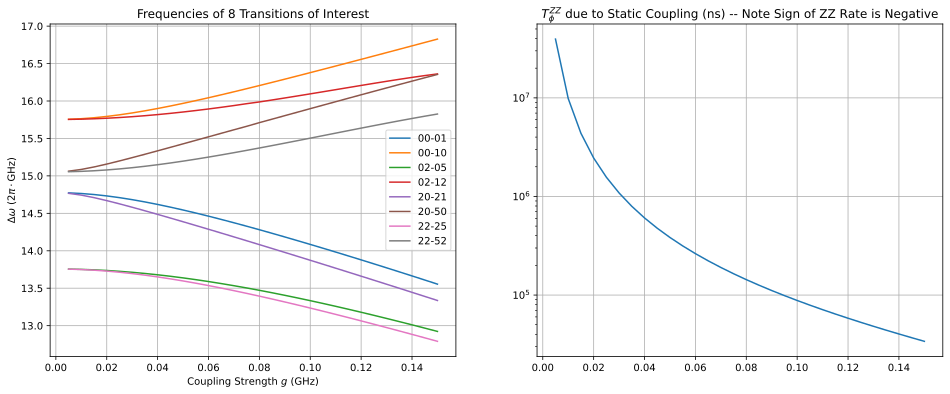

In [ ]:
trans = {(0,0): [(0,1), (1,0)],
         (0,2): [(1,2), (0,5)],
         (2,0): [(2,1), (5,0)],
         (2,2): [(2,5), (5,2)]}         
g_vec = np.linspace(0.005, 0.15, num=30)

state_list = []
dw_list = []
mat_list= []
zz_list = []

for g_val in tqdm(g_vec):
    hspace.interaction_list[0].g_strength = g_val
    hspace.generate_lookup()
    # Record ZZ rate
    zz_list.append(np.abs(utils.transition_frequency(hspace, (2,2))) -
                    np.abs(utils.transition_frequency(hspace, (0,2))) -
                    np.abs(utils.transition_frequency(hspace, (2,0))))
    for s1 in trans:
        for s2 in trans[s1]:
            # Try both options of other state
            if g_val == g_vec[0]:
                state_list.append('%d'%s1[0] + '%d'%s1[1] + '-' + '%d'%s2[0] + '%d'%s2[1])
            dw_list.append(np.abs(utils.transition_frequency(hspace, s1, s2)))
            m1_val = np.abs(mat1[hspace.dressed_index(s1), hspace.dressed_index(s2)])
            m2_val = np.abs(mat2[hspace.dressed_index(s1), hspace.dressed_index(s2)])
            mat_list.append(max(np.max(m1_val), np.max(m2_val)))

# Reset g
hspace.interaction_list[0].g_strength = g
hspace.generate_lookup()

zz_list = np.array(zz_list)
dw_list = np.array(dw_list).reshape(len(g_vec), len(state_list))        
mat_list = np.array(mat_list).reshape(len(g_vec), len(state_list))

f, ax = plt.subplots(figsize=(16,6), ncols=2)
trans_order = {}
for i in range(int(len(state_list)/2)):
    trans1 = state_list[2*i]
    trans2 = state_list[2*i+1]
    data = dw_list[:,2*i:2*(i+1)]
    order = np.argsort(data, axis=1)
    for ii in range(order.shape[0]):
        data[ii,:] = data[ii,order[ii]]
    trans_order[(trans1, trans2)] = order
    if order[0,0] == 1:
        temp = trans2
        trans2 = trans1
        trans1 = temp

    ax[0].plot(g_vec, data[:,0], label=trans1)
    ax[0].plot(g_vec, data[:,1], label=trans2)

ax[0].set_title("Frequencies of 8 Transitions of Interest")
ax[0].set_ylabel(r"$\Delta \omega$ ($2\pi\cdot$GHz)")
ax[0].set_xlabel(r"Coupling Strength $g$ (GHz)")
ax[0].grid()
ax[0].legend()

ax[1].set_title(r"$T_\phi^{ZZ}$ due to Static Coupling (ns) -- Note Sign of ZZ Rate is Negative")
ax[1].grid()
ax[1].plot(g_vec, np.abs(2*np.pi/np.array(zz_list)))
ax[1].set_yscale("log");

# Simulate CZ gate

Begin by redefining the system with the chosen parameters (also re-define so we don't get lots of scqubits warnings about changing parameters):

In [ ]:
g = 0.091
# g = 0.15
# g = 0.04
# g = 0.02

# Number of eigenstates for each qubit to consider in the joint system
trunc_dim = 10 


# System Constants for each qubit
ng_theta = [0., 0.]
phi_ext = [0, 0]
EJ = [6.013, 6.013*0.9]
EL = [0.377, 0.377]
EC_theta = [0.092, 0.092 ] 
EC_phi = [1.142, 1.142 ]  

# Define the qubit and system
phi_grid = scq.Grid1d(-6*np.pi, 6*np.pi, 200)
zp1 = scq.ZeroPi(grid = phi_grid,
                 EJ = EJ[0],
                 EL = EL[0],
                 ECJ = 2 * EC_phi[0],
                 ECS = 2 * EC_theta[0],
                 EC = None,
                 ng = ng_theta[0],
                 flux = phi_ext[0],
                 ncut = 30,
                 truncated_dim = trunc_dim)
zp2 = scq.ZeroPi(grid = phi_grid,
                 EJ = EJ[1],
                 EL = EL[1],
                 ECJ = 2 * EC_phi[1],
                 ECS = 2 * EC_theta[1],
                 EC = None,
                 ng = ng_theta[1],
                 flux = phi_ext[1],
                 ncut = 30,
                 truncated_dim = trunc_dim)
hspace = scq.HilbertSpace([zp1, zp2])

hspace.add_interaction(g=g, op1=zp1.n_theta_operator, op2=zp2.n_theta_operator)
hspace.generate_lookup()


computational_subspace = [(0,0), (0,2), (2,0), (2,2)]


n_a =  hspace.op_in_dressed_eigenbasis(op=zp1.n_theta_operator)
n_b =  hspace.op_in_dressed_eigenbasis(op=zp2.n_theta_operator)

### Truncation: only consider states that either couple strongly to the computational levels or our intended fifth state (5,2):

In [ ]:
state0 = (2,2)
state5 = (5,2)

trunc_states = []
trunc_states += computational_subspace
trunc_states += [state5]
# trunc_states += coupled

thresh = 0.1
for i in [hspace.dressed_index(x) for x in trunc_states]:
    for j in range(n_a.shape[0]):
        if np.abs(n_a[i,j]) > thresh:
            j_state = hspace.bare_index(j)
            if j_state not in trunc_states:
                trunc_states.append(j_state)
        if np.abs(n_b[i,j]) > thresh:
            j_state = hspace.bare_index(j)
            if j_state not in trunc_states:
                trunc_states.append(j_state)

trunc_i = [hspace.dressed_index(x) for x in trunc_states]
total_truncation = len(trunc_i)

trunc_states, len(trunc_states)

([(0, 0),
  (0, 2),
  (2, 0),
  (2, 2),
  (5, 2),
  (0, 1),
  (1, 0),
  (0, 5),
  (1, 2),
  (5, 0),
  (0, 7),
  (2, 1),
  (7, 0),
  (1, 4),
  (2, 5),
  (2, 7),
  (8, 1),
  (7, 2),
  (8, 0),
  (2, 4),
  (1, 5),
  (4, 2),
  (2, 8),
  (8, 2),
  (5, 5),
  (4, 8),
  (8, 4),
  (5, 7),
  (7, 5)],
 29)

In [ ]:
## Express the Hamiltonian and drive in the dressed eigenbasis and truncate

# Hamiltonian in dressed eigenbasis
(evals,) = hspace["evals"]
# The factor of 2pi converts the energy to GHz so that the time is in units of ns
diag_dressed_hamiltonian = (
    2 * np.pi * qt.Qobj(np.diag(evals), dims=[hspace.subsystem_dims] * 2)
)
diag_dressed_hamiltonian_trunc = utils.truncate(diag_dressed_hamiltonian, trunc_i)

#get the representation of the n_b operator in the dressed eigenbasis of the composite system
n_a_trunc = 2 * np.pi * utils.truncate(n_a, trunc_i)
n_b_trunc = 2 * np.pi * utils.truncate(n_b, trunc_i)

## Define the Hamiltonian functions for qutip

# Expectation Operators
e_ops = [qt.basis(total_truncation, i) * qt.basis(total_truncation, i).dag() for i in range(total_truncation)]

# Drive Coefficient on qubit A
def drive_coeff_A(t: float, args: dict) -> float:
    A = args.get('drive_amp_A', 0)
    if A == 0:
        return 0
    detuning = args.get("detuning_A", 0)
    envelope = args.get("envelope_fn_A", lambda t: 1)
    wd = args.get('drive_freq_A', 0) + detuning
    return A * envelope(t) *np.cos(wd * t)

# Drive Coefficient on qubit B
def drive_coeff_B(t: float, args: dict) -> float:
    A = args.get('drive_amp_B', 0)
    if A == 0:
        return 0
    detuning = args.get("detuning_B", 0)
    envelope = args.get("envelope_fn_B", lambda t: 1)
    wd = args.get('drive_freq_B', 0) + detuning
    return A * envelope(t) *np.cos(wd * t)

# time-dependent drive Hamiltonian
H_qbt_drive = [
    diag_dressed_hamiltonian_trunc,
    [n_a_trunc, drive_coeff_A],
    [n_b_trunc, drive_coeff_B]
]

options = qt.Options(nsteps=10000, store_states=True)

## For calculating gate fidelity later

# Factor global phase so that upper-left corner of matrix is real
def remove_global_phase(op):
    return op * np.exp(-1j * cmath.phase(op[0, 0]))

# The process for obtaining the Z rotations is taken from page 3 of Nesterov et al., at the
# bottom of the paragraph beginning, "To model gate operation..."
def dphi(prop, idx):
    return (-np.angle(prop[idx[0], idx[1]]) 
            +np.angle(prop[0,0]))

def cz_fidelity(prop):
    # product of single-qubit Z-gates
    Uz = remove_global_phase(qt.tensor(rz(dphi(prop, (2,2))), rz(dphi(prop, (1,1)))))
    Ucprime = remove_global_phase(Uz * prop)
    #fidelity measure given on page 3 of Nesterov et al.
    fidelity = np.round( ((Ucprime.dag() * Ucprime).tr() 
                    + np.abs((Ucprime.dag() * cz_gate()).tr()) ** 2) / 20, 6)
    A = np.angle(Ucprime[3,3])
    return fidelity, A, Ucprime

### Actually Do The Gate:

2it [00:05,  2.66s/it]
2it [00:06,  3.12s/it]


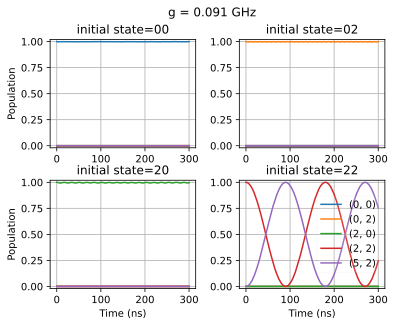

In [ ]:
# Pulse parameters optimized by hand
omega_d = utils.transition_frequency(hspace, state0, state5)
drive_amp = 0.005    #.005
Tgate = 300
drive_detuning = 0
num_t = 1000
tlist = np.linspace(0, Tgate, num_t)  # total time
pulse_args = {'drive_amp_A': drive_amp, 'drive_freq_A': omega_d, 'detuning_A': drive_detuning}


result = {}
logi_state = [0,2]
for idx, state_i in enumerate(logi_state):
    for jdx, state_j in tqdm(enumerate(logi_state)):
        # This simulation is just for viewing the affect of the pulse
        result[idx, jdx] = qt.mesolve(
            H_qbt_drive, 
            qt.basis(total_truncation, trunc_states.index((state_i,state_j))), 
            tlist, 
            e_ops=e_ops[:4] + [e_ops[trunc_states.index(state5)]],
            args=pulse_args,
            options=options
        )

#####################################################################################
##### Drive and Population Visualization #######
fig, ax = plt.subplots(figsize=(6,4.5), nrows=2, ncols=2)
#ax[0].plot(tlist, drive)
fig.suptitle('g = %.3f GHz'%g, fontsize=12)
plt.subplots_adjust(wspace=0.3, hspace=0.3)
for idx, state_i in enumerate(logi_state):
    for jdx, state_j in enumerate(logi_state):
        for kdx, res in zip(computational_subspace + [state5], result[idx,jdx].expect):    
            ax[idx][jdx].plot(tlist, res, label=kdx)
        ax[idx][jdx].set_ylim(-0.02,1.02)
        ax[idx][jdx].grid()
        ax[idx][jdx].set_title('initial state='+str(state_i)+str(state_j))
    ax[1][idx].set_xlabel('Time (ns)')
    ax[idx][0].set_ylabel('Population')
    
handles, labels = ax[1][1].get_legend_handles_labels()
ax[1][1].legend(handles[::-1],labels[::-1], loc=1)
ax[1][1].legend().get_frame().set_alpha(0.1)

In [ ]:
buff = 20
min_idx = np.argmin(result[logi_state.index(state0[0]),logi_state.index(state0[1])].expect[-1][buff:]) + buff
print("gate time:", np.round(tlist[min_idx],2), "ns, starting state pop:", 
np.round(np.abs(result[logi_state.index(state0[0]),logi_state.index(state0[1])].expect[trunc_states.index(state0)][min_idx])**2,6))
print("--------------------------")

# Make Propagator
prop = np.zeros((4,4), np.complex128)
for idx, state_i in enumerate(logi_state[:]):
    for jdx, state_j in enumerate(logi_state[:]):
        final_state = result[idx,jdx].states[min_idx].dag()
        for i, state in enumerate(computational_subspace):
            prop[i, 2*idx+jdx] = (final_state*qt.basis(total_truncation, i)).data.todense()
prop = qt.Qobj(prop)
prop.dims = [[2,2],[2,2]]

fidelity, phase, U = cz_fidelity(prop)

print('CPhase (units of pi) =',np.round(phase/np.pi,5),'; Fidelity =',np.round(fidelity, 5))
U


gate time: 180.18 ns, starting state pop: 0.999919
--------------------------
CPhase (units of pi) = -0.9445 ; Fidelity = 0.99282


Quantum object: dims = [[2, 2], [2, 2]], shape = (4, 4), type = oper, isherm = False
Qobj data =
[[ 9.99095823e-01+0.00000000e+00j -2.85613281e-07-9.53770736e-08j
   1.80790029e-07-3.24094242e-07j -1.86119767e-08-4.38554287e-09j]
 [-4.43143042e-07-1.15056227e-07j  9.98333265e-01+0.00000000e+00j
   1.27614979e-04-1.89856715e-05j -1.15791120e-06+5.71586021e-07j]
 [-1.47241653e-06-1.34226641e-06j -1.01515964e-04-8.09471296e-05j
   9.97300291e-01+0.00000000e+00j  2.51867617e-07+1.29062188e-07j]
 [-1.62799969e-08-5.34893631e-09j  2.82249046e-06+7.37466719e-07j
   4.75286724e-07+1.98262802e-07j -9.84817988e-01-1.73472809e-01j]]

# 4) Predict Geometric Phase Accumulation

Predict the phase accumulation by calculating the area subtended by round trip on the bloch sphere:

In [ ]:

Ht = lambda t: qt.Qobj(H_qbt_drive[0] + H_qbt_drive[1][0]*H_qbt_drive[1][1](t, args=pulse_args) + H_qbt_drive[2][0]*H_qbt_drive[2][1](t, args=pulse_args))
results = result[logi_state.index(state0[0]), logi_state.index(state0[1])]
i1 = trunc_states.index(state0)
i2 = trunc_states.index(state5)
diag_H = 2 * np.pi * qt.Qobj(np.diag([hspace.energy_by_bare_index(state0), hspace.energy_by_bare_index(state5)]))
psi_list = [(1.0j*tlist[x]*diag_H).expm()*qt.Qobj(results.states[x][[i1, i2]]) for x in range(len(results.states))][:min_idx]

# Bloch Sphere Coordinates
xx = qt.expect(qt.sigmax(), psi_list)
yy = qt.expect(qt.sigmay(), psi_list)
zz = qt.expect(qt.sigmaz(), psi_list)

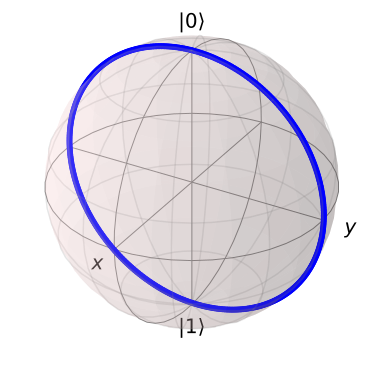

In [ ]:
b = qt.Bloch()
b.add_points([xx, yy, zz])
b.show()

(-1.0092057129350067, 0.9912298692586117)

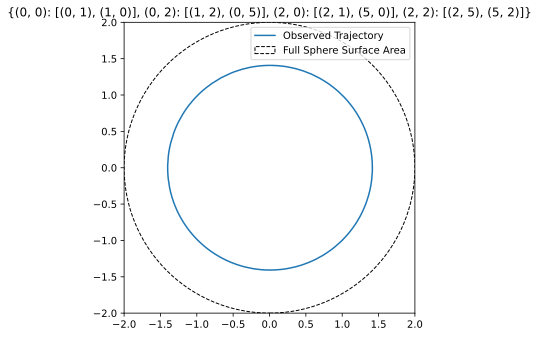

In [ ]:
# 2d equal area projection of the surface area of a sphere
def labmert_proj(xx, yy, zz):
    XX = np.sqrt(2/(1-zz))*xx
    YY = np.sqrt(2/(1-zz))*yy
    return XX, YY

def PolyArea(x,y):
    return 0.5*np.abs(np.dot(x,np.roll(y,1))-np.dot(y,np.roll(x,1)))

def poly_Area(vertices):
    return np.sum( [0.5, -0.5] * vertices * np.roll( np.roll(vertices, 1, axis=0), 1, axis=1) )

def geometric_phase_integral(xx, yy, zz):
    phi = np.arctan2(yy, xx)
    dphi = np.diff(phi, append=phi[0])
    costheta = zz
    return np.sum(-0.5*(1-costheta)*dphi)



XX, YY = labmert_proj(zz, yy, xx)
plt.plot(XX, YY, label = "Observed Trajectory")
ax = plt.gca()
ax.set_aspect(1)
ax.set_title(trans)
ax.set_xlim((-2,2))
ax.set_ylim((-2,2))
circle = plt.Circle((0, 0), 2, edgecolor='k', fill=False, ls="--", label = "Full Sphere Surface Area")
ax.add_patch(circle)
plt.tight_layout()
plt.gca().set_aspect(1)
plt.legend()
factor2 = -0.5*(4-PolyArea(XX, YY)/np.pi)
factor2, (geometric_phase_integral(xx, yy, zz)/np.pi)%2

It's not quite the observed phase, we're off by about 5%. Try additionally considering the geometric phase accumulated by the other states via their partial Rabi oscillations. Note that:

$$
U = 
\begin{pmatrix} 
e^{i\varphi_1} & 0 & 0 & 0 \\
0 & e^{i\varphi_2} & 0 & 0 \\
0 & 0 & e^{i\varphi_3} & 0 \\
0 & 0 & 0 & e^{i\varphi_4} \\
\end{pmatrix} = 
\begin{pmatrix} 
1 & 0 & 0 & 0 \\
0 & e^{i(\varphi_2 - \varphi_1)} & 0 & 0 \\
0 & 0 & e^{i(\varphi_3 - \varphi_1)} & 0 \\
0 & 0 & 0 & e^{i(\varphi_4 - \varphi_1)} \\
\end{pmatrix}
$$

By single qubit rotations we can push all the phase onto the $|11\rangle_L$ state:

$$
U [Rz_a(-(\varphi_3 - \varphi_1)) \otimes Rz_b(-(\varphi_2 - \varphi_1))] = \begin{pmatrix} 
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & e^{i(\varphi_4 + \varphi_1 - \varphi_2 - \varphi_3)} \\
\end{pmatrix}
$$

meaning we need to add phases accumulated by the $|00\rangle and $|22\rangle$ states and subtract phases accumulated by the $|02\rangle$ and $|20\rangle$ states.
We'll consider seven transitions, all except for the additional $|22\rangle$ transition, as that one would not be well described by a two state system. The full treatment would be to consider the geometric phase in a three state system, see: [Geometric Phases for Three State Systems](https://arxiv.org/pdf/quant-ph/9902061.pdf). However, this should hopefully give us a clear enough picture.


In [ ]:
# Assumes first one is the desired transition
all_trans = [((2,2), (5,2)),
             ((2,0), (5,0)),
             ((0,2), (1,2)),
             ((0,0), (1,0)),
             ((0,0), (0,1)),
             ((2,0), (2,1)),
             ((0,2), (0,5))]

def expected_phase_sim(w0, detuning, transitions = all_trans, drive_amp = drive_amp, hspace=hspace,
                        return_contrib=False, plot_loops=False):
    
    phases = {}
    sims = {}
    total = 0
    if plot_loops:
        f, ax = plt.subplots(nrows=2, ncols=4)
        f.set_size_inches((15,9))
        plt.suptitle("Trajectories on the Surface of the Bloch Sphere (blue is beginning, yellow is end)")

    for itrans, trans in enumerate(transitions):

        i1 = trunc_states.index(trans[0])
        i2 = trunc_states.index(trans[1])
        Delta = w0 + detuning - utils.transition_frequency(hspace, trans[0], trans[1])
        eff_drive = np.abs(drive_amp*H_qbt_drive[1][0][i1, i2])
        rabi = np.sqrt(eff_drive**2 + Delta**2)
        osc_freq = np.sqrt((detuning**2 + rabi**2))/2

        period = np.pi/osc_freq
        if itrans == 0:
            main_period = period
            # print("main period:",period)
        

        # print("------------------")
        # print(trans)
        # print("Delta", Delta)
        # print("eff drive", eff_drive)
        # print("rabi", rabi)
        # print("detuning", detuning)
        # print("period", period)


        # Calculate the geometric phase
        pulse_args = {'drive_amp_A': drive_amp, 'drive_freq_A': w0, "detuning_A": detuning}
        tlist = np.linspace(0, 2*period, 1000)
        results = qt.mesolve(
                    H_qbt_drive, 
                    qt.basis(total_truncation, i1), 
                    tlist,
                    args=pulse_args,
                    options=options
        )
        sims[trans[0]] = results


        Ht = lambda t: qt.Qobj(H_qbt_drive[0] + H_qbt_drive[1][0]*H_qbt_drive[1][1](t, args=pulse_args) + H_qbt_drive[2][0]*H_qbt_drive[2][1](t, args=pulse_args))
        diag_H = 2 * np.pi * qt.Qobj(np.diag([hspace.energy_by_bare_index(state0), hspace.energy_by_bare_index(state5)]))
        psi_list = [(1.0j*tlist[x]*diag_H).expm()*qt.Qobj(results.states[x][[i1, i2]]) for x in range(len(results.states))]


        pop_in_ending = qt.expect(qt.basis(2, 1) * qt.basis(2, 1).dag(), psi_list)

        # Check to make sure we got the period right
        if pop_in_ending[int(len(pop_in_ending)/2)] < 0.0001:
            period_idx = int(len(pop_in_ending)/2)
        else:
            peaks = find_peaks(gaussian_filter(pop_in_ending, 10))
            period_idx = peaks[0][0]*2
            period = tlist[period_idx]
            
            print("period", period)
            print("peaks:")
            print(peaks)
            print(tlist[period_idx], pop_in_ending[period_idx])

        xx = qt.expect(qt.sigmax(), psi_list)[:period_idx]
        yy = qt.expect(qt.sigmay(), psi_list)[:period_idx]
        zz = qt.expect(qt.sigmaz(), psi_list)[:period_idx]

        XX, YY = labmert_proj(zz, yy, xx)

        # Calculate "handidness of trajectory" using right hand rule
        test_point = (XX[int(period_idx/4)], YY[int(period_idx/4)])
        starting_point = (XX[0], YY[0])

        # Top Right quadrant -- Into Page
        if test_point[0] > starting_point[0] and test_point[1] > starting_point[1]:
            sign = -1
        # Top Left quadrant -- Out of Page
        elif test_point[0] < starting_point[0] and test_point[1] > starting_point[1]:
            sign = 1
        # Bottom left quadrant -- Into Page
        elif test_point[0] < starting_point[0] and test_point[1] < starting_point[1]:
            sign = -1
        # Bottom right quadrant -- Out of page
        elif test_point[0] > starting_point[0] and test_point[1] < starting_point[1]:
            sign = 1
        else:
            raise ValueError("Trajectory Doesn't Move")

        if plot_loops:
            fi = int(itrans/4)
            fj = itrans%4
            ax[fi, fj].scatter(XX, YY, marker = '.', c = np.arange(len(XX)))
            ax[fi, fj].set_title(f"{trans}: Handedness = {sign}")
            ax[fi, fj].set_aspect(1)
        
        area = PolyArea(XX, YY)
        phase_factor = sign*np.abs(0.5*(area)*(main_period/period)/np.pi % 2)

        # Put between -pi and pi
        if np.abs(phase_factor) > 1:
            phase_factor = -(np.abs(phase_factor)/phase_factor)*(2-np.abs(phase_factor))



        if itrans == 0:
            starting_state = trans[0]
        
        phases[trans] = phase_factor
        if trans[0] not in [(0,0), starting_state]:
            phases[trans]*=-1
        
            
        total += phases[trans]
    
    if plot_loops:
        plt.tight_layout()

    if return_contrib:
        return total, phases 
    else:
        return total

(-0.9468871291946865,
 {((2, 2), (5, 2)): -0.9908563916048921,
  ((2, 0), (5, 0)): 0.03322739406024416,
  ((0, 2), (1, 2)): 0.03383226153041809,
  ((0, 0), (1, 0)): -0.020391977111552412,
  ((0, 0), (0, 1)): 0.005290961545703801,
  ((2, 0), (2, 1)): -0.006457704222839063,
  ((0, 2), (0, 5)): -0.0015316733917689136})

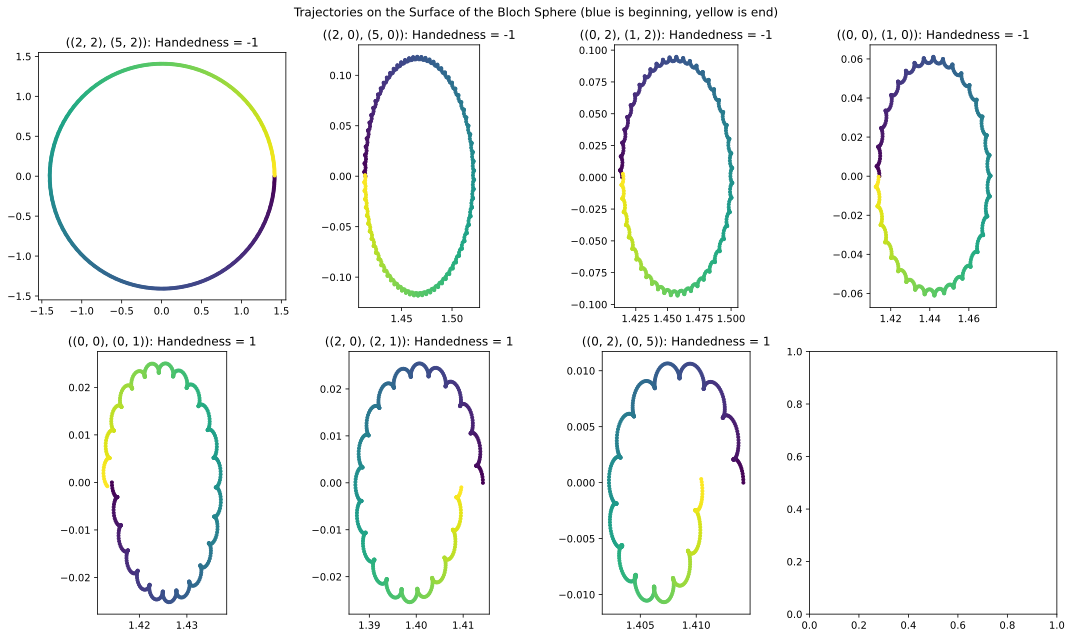

In [ ]:
stuff = expected_phase_sim(omega_d, 0, return_contrib=True, plot_loops=True)
geom_factor = stuff[0]
stuff

In [ ]:
# Also consider the static ZZ coupling over the course of the gate -- small compared to the geometric phase over the time of the gate
zeta =   -2*np.pi*(hspace.energy_by_bare_index((2,2), subtract_ground=True) -
                hspace.energy_by_bare_index((2,0), subtract_ground=True) -
                hspace.energy_by_bare_index((0,2), subtract_ground=True))
zeta_factor = np.round(zeta*tlist[min_idx]/np.pi, 5)
zeta_factor

0.00332

In [ ]:
# Push to between -pi/pi
if np.abs(geom_factor) > 1:
    geom_factor = -(np.abs(geom_factor)/geom_factor)*(2-np.abs(geom_factor))
total_pred_phase = geom_factor + zeta_factor

np.round(phase/np.pi, 5), np.round(total_pred_phase, 5)

(-0.9445, -0.94357)

Matches to four decimal places!

### Try with a drive detuning:

Begin by making a function that will calculate fidelity, phase, and an effective U for a given detuning:

In [13]:
def drive_fidelity_square(drive_detuning, drive_amp= 0.005, Tgate=300, num_t=1000, state0=(2,2), state5=(5,2)):
        
    omega_d = utils.transition_frequency(hspace, state0, state5)
    tlist = np.linspace(0, Tgate, num_t)  # total time
    pulse_args = {'drive_amp_A': drive_amp, 'drive_freq_A': omega_d, 'detuning_A': drive_detuning}

    result = {}
    logi_state = [0,2]
    for idx, state_i in enumerate(logi_state):
        for jdx, state_j in enumerate(logi_state):
            # This simulation is just for viewing the affect of the pulse
            result[idx, jdx] = qt.mesolve(
                H_qbt_drive, 
                qt.basis(total_truncation, trunc_states.index((state_i,state_j))), 
                tlist, 
                e_ops=e_ops[:4] + [e_ops[trunc_states.index(state5)]],
                args=pulse_args,
                options=options
            )

    buff = 20
    min_idx = np.argmin(result[logi_state.index(state0[0]),logi_state.index(state0[1])].expect[-1][buff:]) + buff

    # Make Propagator
    prop = np.zeros((4,4), np.complex128)
    for idx, state_i in enumerate(logi_state[:]):
        for jdx, state_j in enumerate(logi_state[:]):
            final_state = result[idx,jdx].states[min_idx].dag()
            for i, state in enumerate(computational_subspace):
                prop[i, 2*idx+jdx] = (final_state*qt.basis(total_truncation, i)).data.todense()
    prop = qt.Qobj(prop)
    prop.dims = [[2,2],[2,2]]

    fidelity, phase, U = cz_fidelity(prop)
    return fidelity, phase, U

In [14]:
detuning = 0.001
fidelity, phase, U = drive_fidelity_square(detuning)
stuff = expected_phase_sim(omega_d, detuning, return_contrib=True, plot_loops=True)
geom_factor = stuff[0]
print("Detuning:", detuning)
# Push to between -pi/pi
if np.abs(geom_factor) > 1:
    geom_factor = -(np.abs(geom_factor)/geom_factor)*(2-np.abs(geom_factor))
print("Predicted Geometric Phase:", geom_factor)
print("Actual Phase", phase/np.pi)
stuff

AttributeError: 'HilbertSpace' object has no attribute '_out_of_sync_warning_issued'

Detuning: -0.001
Predicted Geometric Phase: 0.9961125866673699
Actual Phase -0.9731588138764399


(0.9961125866673699,
 {((2, 2), (5, 2)): 0.951816731284453,
  ((2, 0), (5, 0)): 0.03346765306267227,
  ((0, 2), (1, 2)): 0.033970717967449195,
  ((0, 0), (1, 0)): -0.020446496849019464,
  ((0, 0), (0, 1)): 0.005274365461391749,
  ((2, 0), (2, 1)): -0.006441438495412293,
  ((0, 2), (0, 5)): -0.0015289457641645661})

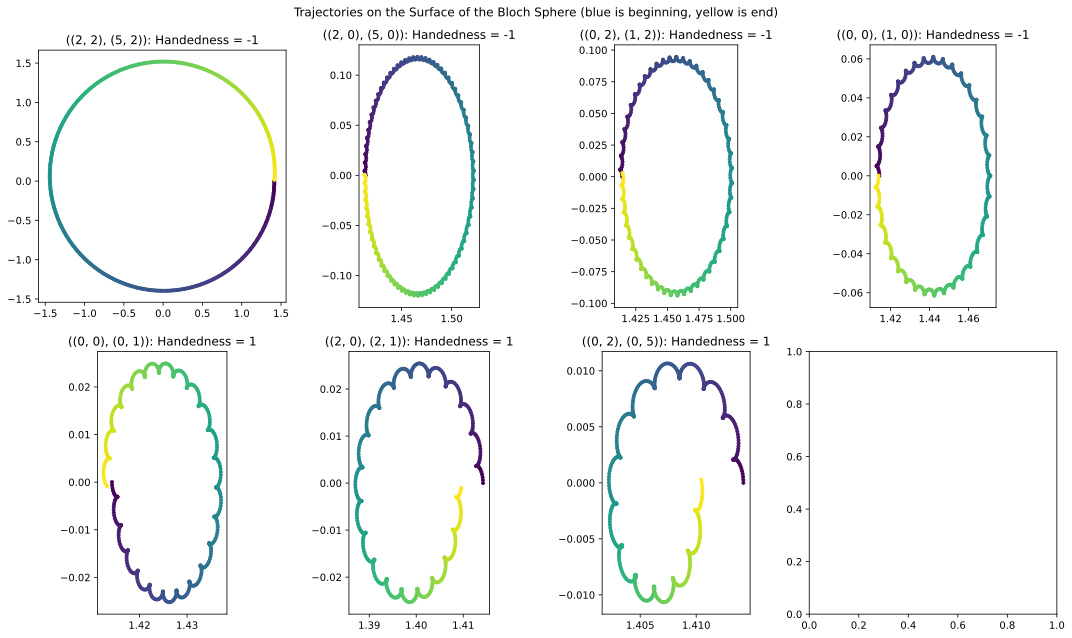

In [ ]:
detuning = -0.001
fidelity, phase, U = drive_fidelity_square(detuning)
stuff = expected_phase_sim(omega_d, detuning, return_contrib=True, plot_loops=True)
geom_factor = stuff[0]
# Push to between -pi/pi
if np.abs(geom_factor) > 1:
    geom_factor = -(np.abs(geom_factor)/geom_factor)*(2-np.abs(geom_factor))
print("Detuning:", detuning)
print("Predicted Geometric Phase:", geom_factor)
print("Actual Phase", phase/np.pi)
stuff

Although the amounts are off by about 2%, we correctly predict the direction of the effect of detuning: detuning down will increase the total phase accumulated, while detuning up will decrease it. I belive this is because the two take different paths along the bloch sphere:

In [ ]:
# Pulse parameters optimized by hand
omega_d = utils.transition_frequency(hspace, state0, state5)
drive_amp = 0.005    #.005
Tgate = 300
drive_detuning = [-0.001, 0.001]
num_t = 1000
tlist = np.linspace(0, Tgate, num_t)  # total time


result = []

for detuning in drive_detuning:
    pulse_args = {'drive_amp_A': drive_amp, 'drive_freq_A': omega_d, 'detuning_A': detuning}
    # This simulation is just for viewing the affect of the pulse
    result.append(qt.mesolve(
        H_qbt_drive, 
        qt.basis(total_truncation, trunc_states.index((state_i,state_j))), 
        tlist, 
        e_ops=e_ops[:4] + [e_ops[trunc_states.index(state5)]],
        args=pulse_args,
        options=options
    ))


In [ ]:
def results_to_coords(results, state0, state5):

    buff = 20
    min_idx = np.argmin(results.expect[-1][buff:]) + buff

    Ht = lambda t: qt.Qobj(H_qbt_drive[0] + H_qbt_drive[1][0]*H_qbt_drive[1][1](t, args=pulse_args) + H_qbt_drive[2][0]*H_qbt_drive[2][1](t, args=pulse_args))
    i1 = trunc_states.index(state0)
    i2 = trunc_states.index(state5)
    diag_H = 2 * np.pi * qt.Qobj(np.diag([hspace.energy_by_bare_index(state0), hspace.energy_by_bare_index(state5)]))
    psi_list = [(1.0j*tlist[x]*diag_H).expm()*qt.Qobj(results.states[x][[i1, i2]]) for x in range(len(results.states))][:min_idx]

    # Bloch Sphere Coordinates
    xx = qt.expect(qt.sigmax(), psi_list)
    yy = qt.expect(qt.sigmay(), psi_list)
    zz = qt.expect(qt.sigmaz(), psi_list)

    return xx, yy, zz

coords = [results_to_coords(x, state0, state5) for x in result]

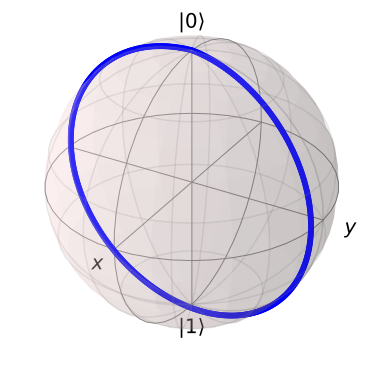

In [ ]:
b = qt.Bloch()
b.add_points(coords[0])
b.show()

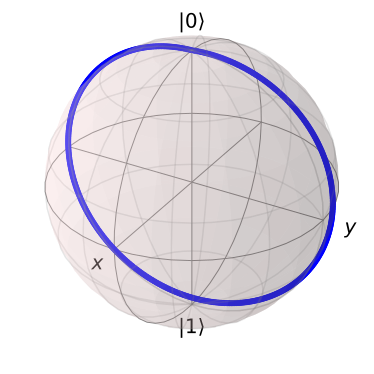

In [ ]:
b = qt.Bloch()
b.add_points(coords[1])
b.show()

You have to look closely, but the two trajectories tilt in different ways. This effectively changes the handidness of the trajectory, thus changing which other phases you add constructively and destructively with. By detuning down, the phase should pass through a point where all of them add up to $\pi$.

# 5) Optimize Gate:

## Square Pulse:

In [ ]:
from scipy.optimize import brute, minimize
def fidelity_optimize_func(x, *args):
    return drive_fidelity_square(x[0], drive_amp=args[0], Tgate=args[1])[0]

x0, fval, grid, Jout = brute(fidelity_optimize_func, ((-0.005, 0.005),), Ns=201, finish=None, full_output=True, workers=4, args=(0.005,300))
np.savez("sweep_A_005.npz", x0=x0, fval=fval, grid=grid, Jout=Jout)


NameError: name 'drive_fidelity_square' is not defined

In [ ]:
plt.plot(grid, 1-Jout)
plt.xlabel(r"Detuning $\delta$")
plt.ylabel("Coherent Error (1 - Fidelity)")
plt.yscale("log")
plt.title("Infidelity (Drive Amp = 0.005)")
plt.grid()

We can't get too high, likely due to leakage outside of our computational subspace. Try lowering the drive power.

In [ ]:
# Pulse parameters optimized by hand
omega_d = utils.transition_frequency(hspace, state0, state5)
drive_amp = 0.002    #.005
Tgate = 500
drive_detuning = 0
num_t = 1000
tlist = np.linspace(0, Tgate, num_t)  # total time
pulse_args = {'drive_amp_A': drive_amp, 'drive_freq_A': omega_d, 'detuning_A': drive_detuning}


result = {}
logi_state = [0,2]
for idx, state_i in enumerate(logi_state):
    for jdx, state_j in tqdm(enumerate(logi_state)):
        # This simulation is just for viewing the affect of the pulse
        result[idx, jdx] = qt.mesolve(
            H_qbt_drive, 
            qt.basis(total_truncation, trunc_states.index((state_i,state_j))), 
            tlist, 
            e_ops=e_ops[:4] + [e_ops[trunc_states.index(state5)]],
            args=pulse_args,
            options=options
        )

#####################################################################################
##### Drive and Population Visualization #######
fig, ax = plt.subplots(figsize=(6,4.5), nrows=2, ncols=2)
#ax[0].plot(tlist, drive)
fig.suptitle('g = %.3f GHz'%g, fontsize=12)
plt.subplots_adjust(wspace=0.3, hspace=0.3)
for idx, state_i in enumerate(logi_state):
    for jdx, state_j in enumerate(logi_state):
        for kdx, res in zip(computational_subspace + [state5], result[idx,jdx].expect):    
            ax[idx][jdx].plot(tlist, res, label=kdx)
        ax[idx][jdx].set_ylim(-0.02,1.02)
        ax[idx][jdx].grid()
        ax[idx][jdx].set_title('initial state='+str(state_i)+str(state_j))
    ax[1][idx].set_xlabel('Time (ns)')
    ax[idx][0].set_ylabel('Population')
    
handles, labels = ax[1][1].get_legend_handles_labels()
ax[1][1].legend(handles[::-1],labels[::-1], loc=1)
ax[1][1].legend().get_frame().set_alpha(0.1)

In [ ]:
buff = 20
min_idx = np.argmin(result[logi_state.index(state0[0]),logi_state.index(state0[1])].expect[-1][buff:]) + buff
print("gate time:", np.round(tlist[min_idx],2), "ns, starting state pop:", 
np.round(np.abs(result[logi_state.index(state0[0]),logi_state.index(state0[1])].expect[trunc_states.index(state0)][min_idx])**2,6))
print("--------------------------")
# Make Propagator
prop = np.zeros((4,4), np.complex128)
for idx, state_i in enumerate(logi_state[:]):
    for jdx, state_j in enumerate(logi_state[:]):
        final_state = result[idx,jdx].states[min_idx].dag()
        for i, state in enumerate(computational_subspace):
            prop[i, 2*idx+jdx] = (final_state*qt.basis(total_truncation, i)).data.todense()
prop = qt.Qobj(prop)
prop.dims = [[2,2],[2,2]]
fidelity, phase, U = cz_fidelity(prop)
print("fidelity", fidelity)
print("phase", phase/np.pi)
U

In [ ]:
x0, fval, grid, Jout = brute(fidelity_optimize_func, ((-0.002, 0),), Ns=101, full_output=True, finish=None, workers=4, args=(0.002,500))

In [ ]:
np.savez("sweep_A_002.npz", x0=x0, fval=fval, grid=grid, Jout=Jout)

In [ ]:
f = plt.figure()
f.set_size_inches((8,4))
plt.plot(grid, 1-Jout)
plt.xlabel(r"Detuning $\delta$")
plt.ylabel("Coherent Error (1 - Fidelity)")
plt.yscale("log")
plt.title("Infidelity (Drive Amp = 0.002)")
plt.tight_layout()
plt.grid()

## Gaussian Pulse:

In [ ]:
# Pulse parameters optimized by hand
omega_d = utils.transition_frequency(hspace, state0, state5)
# drive_amp = 0.01    #.005
# Tgate = 150
drive_amp = 0.005    #.005
Tgate = 300
drive_detuning = 0
num_t = 1000
tlist = np.linspace(0, Tgate, num_t)  # total time
pulse_args = {'drive_amp_A': drive_amp, 'drive_freq_A': omega_d,
              'detuning_A': drive_detuning,
              "envelope_fn_A": lambda t: utils.gaussian_envelope(t, Tgate)}


result = {}
logi_state = [0,2]
for idx, state_i in enumerate(logi_state):
    for jdx, state_j in tqdm(enumerate(logi_state)):
        # This simulation is just for viewing the affect of the pulse
        result[idx, jdx] = qt.mesolve(
            H_qbt_drive, 
            qt.basis(total_truncation, trunc_states.index((state_i,state_j))), 
            tlist, 
            e_ops=e_ops[:4] + [e_ops[trunc_states.index(state5)]],
            args=pulse_args,
            options=options
        )

#####################################################################################
##### Drive and Population Visualization #######
fig, ax = plt.subplots(figsize=(6,4.5), nrows=2, ncols=2)
#ax[0].plot(tlist, drive)
fig.suptitle('g = %.3f GHz'%g, fontsize=12)
plt.subplots_adjust(wspace=0.3, hspace=0.3)
for idx, state_i in enumerate(logi_state):
    for jdx, state_j in enumerate(logi_state):
        for kdx, res in zip(computational_subspace + [state5], result[idx,jdx].expect):    
            ax[idx][jdx].plot(tlist, res, label=kdx)
        ax[idx][jdx].set_ylim(-0.02,1.02)
        ax[idx][jdx].grid()
        ax[idx][jdx].set_title('initial state='+str(state_i)+str(state_j))
    ax[1][idx].set_xlabel('Time (ns)')
    ax[idx][0].set_ylabel('Population')
    
handles, labels = ax[1][1].get_legend_handles_labels()
ax[1][1].legend(handles[::-1],labels[::-1], loc=1)
ax[1][1].legend().get_frame().set_alpha(0.1)

In [ ]:
min_idx = -1
print("gate time:", np.round(tlist[min_idx],2), "ns, starting state pop:", 
np.round(np.abs(result[logi_state.index(state0[0]),logi_state.index(state0[1])].expect[trunc_states.index(state0)][min_idx])**2,6))
print("--------------------------")
# Make Propagator
prop = np.zeros((4,4), np.complex128)
for idx, state_i in enumerate(logi_state[:]):
    for jdx, state_j in enumerate(logi_state[:]):
        final_state = result[idx,jdx].states[min_idx].dag()
        for i, state in enumerate(computational_subspace):
            prop[i, 2*idx+jdx] = (final_state*qt.basis(total_truncation, i)).data.todense()
prop = qt.Qobj(prop)
prop.dims = [[2,2],[2,2]]
fidelity, phase, U = cz_fidelity(prop)
print("fidelity", fidelity)
print("phase", phase/np.pi)
U

In [ ]:
def drive_fidelity_gaussian(drive_detuning, Tgate, drive_amp= 0.01, num_t=1000, state0=(2,2), state5=(5,2)):
    
    # Pulse parameters optimized by hand
    omega_d = utils.transition_frequency(hspace, state0, state5)
    tlist = np.linspace(0, Tgate, num_t)  # total time
    pulse_args = {'drive_amp_A': drive_amp, 'drive_freq_A': omega_d,
                'detuning_A': drive_detuning,
                "envelope_fn_A": lambda t: utils.gaussian_envelope(t, Tgate)}


    result = {}
    logi_state = [0,2]
    for idx, state_i in enumerate(logi_state):
        for jdx, state_j in enumerate(logi_state):
            # This simulation is just for viewing the affect of the pulse
            result[idx, jdx] = qt.mesolve(
                H_qbt_drive, 
                qt.basis(total_truncation, trunc_states.index((state_i,state_j))), 
                tlist, 
                e_ops=e_ops[:4] + [e_ops[trunc_states.index(state5)]],
                args=pulse_args,
                options=options
            )

    min_idx = -1
    # Make Propagator
    prop = np.zeros((4,4), np.complex128)
    for idx, state_i in enumerate(logi_state[:]):
        for jdx, state_j in enumerate(logi_state[:]):
            final_state = result[idx,jdx].states[min_idx].dag()
            for i, state in enumerate(computational_subspace):
                prop[i, 2*idx+jdx] = (final_state*qt.basis(total_truncation, i)).data.todense()
    prop = qt.Qobj(prop)
    prop.dims = [[2,2],[2,2]]
    fidelity, phase, U = cz_fidelity(prop)

    return fidelity, phase, U

In [ ]:
def fidelity_optimize_func_gauss(x, args):
    return -drive_fidelity_gaussian(x[0], x[1], args)[0]

In [ ]:
x0, fval, grid, Jout = brute(fidelity_optimize_func_gauss, ((-0.005, 0), (250, 350)), Ns=101, full_output=True, finish=minimize, workers=5, args=(0.005,))

In [ ]:
np.savez("sweep_gaussian_A_005.npz", x0=x0, fval=fval, grid=grid, Jout=Jout)

In [ ]:
print("Best point:", x0)
print("Best fidelity:", -fval)

# Y is row coordinate, X is column coordinate
X = grid[0]
Y = grid[1]

# plt.pcolormesh(tp_grid,delta_grid,prob)
f = plt.figure()
plt.pcolormesh(X, Y, np.log10(1+Jout))
plt.colorbar()
plt.title(r"Log of Infidelity: $log_{10}(1-F)$")
plt.xlabel(r"Drive Detuning $\delta = \omega_{22-52} - \omega_{drive}$ ($2 \pi \cdot$ GHz)")
plt.ylabel(r"Gate Time (ns)");

In [ ]:
x0, fval, grid, Jout = brute(fidelity_optimize_func_gauss, ((-0.006, -0.004), (140, 160)), Ns=41, full_output=True, finish=minimize, workers=5, args=(0.01,))

In [ ]:
np.savez("sweep_gaussian_A_01.npz", x0=x0, fval=fval, grid=grid, Jout=Jout)

In [ ]:
print("Best point:", x0)
print("Best fidelity:", -fval)

# Y is row coordinate, X is column coordinate
X = grid[0]
Y = grid[1]

# plt.pcolormesh(tp_grid,delta_grid,prob)
f = plt.figure()
plt.pcolormesh(X, Y, np.log10(1+Jout))
plt.colorbar()
plt.title(r"Log of Infidelity: $log_{10}(1-F)$, (A = 0.01)")
plt.xlabel(r"Drive Detuning $\delta = \omega_{22-52} - \omega_{drive}$ ($2 \pi \cdot$ GHz)")
plt.ylabel(r"Gate Time (ns)");

# Old Code:

In [ ]:
def expected_phase_model(w0, detuning, transitions = all_trans, drive_amp = drive_amp, hspace=hspace,
                        return_contrib=False):
    phases = {}
    total = 0

    for itrans, trans in enumerate(transitions):

        i1 = trunc_states.index(trans[0])
        i2 = trunc_states.index(trans[1])
        Delta = w0 + detuning - utils.transition_frequency(hspace, trans[0], trans[1])
        eff_drive = np.abs(drive_amp*H_qbt_drive[1][0][i1, i2])
        rabi = np.sqrt(eff_drive**2 + Delta**2)
        osc_freq = np.sqrt((detuning**2 + rabi**2))/2
        
        period = np.pi/osc_freq
        if itrans == 0:
            main_period = period

        if Delta >= 0:
            solid_angle = 2*np.pi*(1 - Delta/np.sqrt((eff_drive**2 + Delta**2)))
        else:
            solid_angle = 2*np.pi*(1 - np.abs(Delta)/np.sqrt((eff_drive**2 + Delta**2)))

        # print("------------------")
        # print(trans)
        # print("Delta", Delta)
        # print("eff drive", eff_drive)
        # print("rabi", rabi)
        # print("period", period)
        # print("solid angle", solid_angle)

        phases[trans] = (main_period/period)*(-solid_angle/2)/np.pi

        # if trans[0] not in ((0,0), (2,2)):
        #     phases[trans] *= -1

        total += phases[trans]

    if return_contrib:
        return total, phases 
    else:
        return total